# Méthodes de gradient (I)
Soit $f :\mathcal X \subset {\mathbb R}^n\to{\mathbb R}$ une fonction. Soit $t\in{\mathbb R}$. On appelle *ligne de niveau $t$* l'ensemble des points suivant :
$$
\text{niv}_{t}f = f^{-1}({t}) =\Big\{x\in\mathcal X\mid f(x)= t\Big\}.$$
**Exercice.** Tracé des lignes de niveaux, des gradients 

Soit $(a,b)\in{\mathbb R}^2$. On considère la fonction quadratique
$$
J:\left\{
\begin{array}{rcl}
{\mathbb R}^2 & \longrightarrow & {\mathbb R}
(x,y) & \longmapsto & \frac12 a x^2+ \frac12 b y^2
\end{array}
\right.$$

- Pour différentes valeurs de $a$ et $b$, tracer des lignes de niveau de $J$ sur le carré $[-5,5]\times[-5,5]$.

In [15]:
import numpy as np
import matplotlib.pyplot as plt

<a list of 12 text.Text objects>

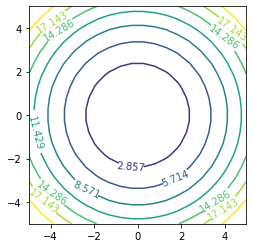

In [29]:
# A vous de jouer
def J(x,y,a,b):
    return 0.5*(a*x**2+b*y**2)
x = np.linspace(-5, 5, 20)
y = np.linspace(-5, 5, 20) 
X, Y = np.meshgrid(x, y) 

a,b = 1.,1.
levels = np.linspace(0,20,8)
Z = J(X,Y,a,b)
plt.axes().set_aspect('equal')
dessin = plt.contour(X,Y,Z,levels=levels)
plt.clabel(dessin,fmt='%.3f',inline = True)

- Pour $(x,y)\in {\mathbb R}^2$, calculer $\nabla J(x,y)$.

In [31]:
# A vous de jouer
def grad_J(u,v,a,b):
    return np.array([0,0])

In [55]:
# A vous de jouer
def grad_J(u,v,a,b):
    return np.array([a*u,b*v])

- Sur la même figure, tracer des lignes de niveau de $J$, puis le vecteur $\nabla J(x_0,y_0)$ au point $(x_0,y_0)\in{\mathbb R}^2$.

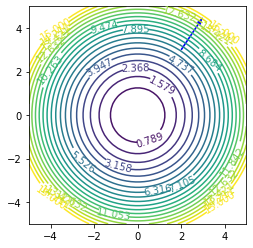

In [56]:
# A vous de jouer
# A vous de jouer

plt.axes().set_aspect('equal')
dessin = plt.contour(X,Y,Z,levels=levels)
plt.clabel(dessin,fmt='%.3f',inline = True)

x0,y0 = 2,3
grad = grad_J(x0,y0,1.,1.)
plt.quiver(x0,y0,grad[0],grad[1], angles = 'xy', scale_units = 'xy', scale=2, color='blue')


In [48]:
grad

array([[-10.        ,  -8.94736842,  -7.89473684,  -6.84210526,
         -5.78947368,  -4.73684211,  -3.68421053,  -2.63157895,
         -1.57894737,  -0.52631579,   0.52631579,   1.57894737,
          2.63157895,   3.68421053,   4.73684211,   5.78947368,
          6.84210526,   7.89473684,   8.94736842,  10.        ],
       [-10.        ,  -8.94736842,  -7.89473684,  -6.84210526,
         -5.78947368,  -4.73684211,  -3.68421053,  -2.63157895,
         -1.57894737,  -0.52631579,   0.52631579,   1.57894737,
          2.63157895,   3.68421053,   4.73684211,   5.78947368,
          6.84210526,   7.89473684,   8.94736842,  10.        ]])

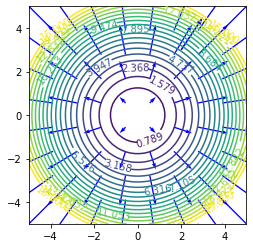

In [54]:
n_points = 10
x = np.linspace(-5,5,5*n_points)
y = np.linspace(-5,5,5*n_points)
X,Y = np.meshgrid(x,y)
xg = np.linspace(-5,5,n_points)
yg = np.linspace(-5,5,n_points)
Xg, Yg = np.meshgrid(xg,yg)
x.shape, y.shape, X.shape, Y.shape
a,b = 1., 1.
levels = np.linspace(0,15,20)
Z = J(x,Y,a,b)
plt.axes().set_aspect('equal')
dessin = plt.contour(X,Y,Z,levels=levels)
plt.clabel(dessin,fmt='%.3f',inline = True)

def grad_J(u,v,a,b):
    return a*u,b*v

x0,y0 = 2,3
gradJ_x0y0 = grad_J(x0,y0,a,b)
gradJ_grid = grad_J(Xg,Yg,a,b)

plt.quiver(x0,y0,gradJ_x0y0[0],gradJ_x0y0[1], angles = 'xy', scale_units = 'xy', scale=2, color='blue')
plt.quiver(Xg,Yg,gradJ_grid[0],gradJ_grid[1], angles = 'xy', scale_units = 'xy', scale=2, color='blue')



- Reprenez la question précédente en traçant le champs de vecteurs $\nabla J(x,y)$ aux points $(x,y) \in [-5,5]^2$.

In [51]:
# A vous de jouer



## Méthode de gradient à pas fixe
Le principe de la méthode de gradient à pas fixe est de faire, à partir d'un vecteur initial $v_0 \in {\mathbb R}^n$, les itérations

$$v_{k+1} = v_k - \varrho \nabla F(v_k)$$

où $\varrho$ est le pas, qui est constant.

**Exercice.** Gradient à pas fixe.
On s'intéresse au cas "d'école" suivant
$$F(x,y) = x^2+ y^2.$$

- Tracer quelques lignes de niveaux.

In [ ]:
# A vous de jouer

- Montrer que la fonction est $\alpha$-convexe, et donner $\alpha$. 

{{Votre réponse ici en LaTeX :}}



- Montrer que la fonction est à gradient Lipschitz, on donnera la constante de Lipschitz. 



- Ecrire une fonction `gf(GradF, v0, rho, tol, NitMax)` qui implémente la méthode de gradient à pas fixe où 

- `GradF` est une fonction qui calcule le gradient de $F$ au point $v = (x,y)$

- `v0` le point initial

- `rho` le pas fixe choisi

- `tol` la tolérance demandée qui servira pour le critère d'arrêt

- `NitMax` le nombre maximal d'itérations autorisé

Cette fonction retourne 

- le minimum trouvé

- la suite des itérés $v_k = (x_k, y_k)_k$

- le nombre d'itérations pour atteindre la tolérance demandée 

- une variable booléenne qui prend la valeur `True` si la méthode a convergé et `False` sinon.

In [59]:
from numpy.linalg import inv, norm, det 


In [68]:
m = 5*np.random.randn(2)
n = 5*np.random.randn(2)

print(m,n,m-n)


[ 4.42012013 -6.66558196] [5.13480489 5.03859259] [ -0.71468476 -11.70417455]


In [101]:
# A vous de jouer

def F(x,y):
    return x**2+y**2

def GradF(x,y):
    return np.array([2*x,2*y])


def gf(GradF, v0, rho, tol, NitMax):
    v_n = v0
    iteres = [v_n]
    

    
    for k in range(NitMax):
        v_nplus1 = v_n - rho*gradF(v_n[0],v_n[1])
        #critere d'arret si |v_n-v_nplus1| < tol
        
        if (np.linalg.norm(v_n-v_nplus1)<tol) or (np.linalg.norm(GradF(v_n[0],v_n[1]))< tol):
            return v_nplus1,iteres,k,True
        
        #mise a jour de v_n
        v_n = v_nplus1
        
        #ajouter v_n a iteres
        iteres.append(v_n)
    return v_nplus1, iteres, k , True


v0 = 5 * np.random.randn(2)
tol = 10e-6
NitMax = 100
rho = 0.1

v_n, iteres, k, converged = gf(GradF, v0, rho,tol, NitMax)

res_array  = np.array(iteres)

x,y  = [], []

for i in iteres:
    x.append[iteres[0]
    y.

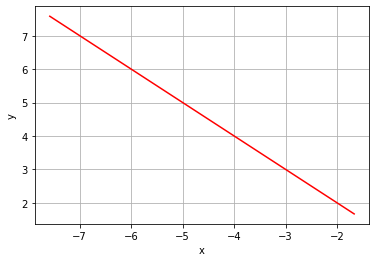

<class 'int'>


In [98]:
plt.plot(res_array[0], res_array[1], '-r')
plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.show()
print(type(2))

- À quelle condition sur `rho` la méthode converge-t-elle ? Quelle est la valeur optimale de `rho`?

{{Votre réponse ici en LaTeX :}}



- Tester votre fonction pour 3 valeurs différentes de `rho`, que constatez vous ? Dans chaque cas, comparer le nombre d'itérations pour la même tolérance.

In [ ]:
# A vous de jouer

**Exercice.** Gradient à pas fixe.
On s'intéresse maintenant au cas suivant
$$F(x,y) = x^2+ 100 y^2.$$

- Appliquer votre fonction `gf` avec `rho = 2/1000` et $v_0 = (1,1)$.

In [ ]:
# A vous de jouer

- Afficher sur un graphique la suite de points $(x_k,y_k)_{k}$.

In [ ]:
# A vous de jouer

- Afficher sur un deuxième graphique la fonction $k\longmapsto (F(x_k,y_k))_{k}$.

In [ ]:
# A vous de jouer

- Afficher sur un troisième graphique la fonction $k \longmapsto(\|(x_k,y_k)\|)_{k}$.

In [ ]:
# A vous de jouer

- Ecrire une fonction `gf2(GradF, v0, rho, tol, NitMax)` comme dans l'exercice précédent, mais en choisissant un autre critère d'arrêt. Exemples : le gradient de $F$ est suffisamment petit, les itérés ne progressent plus suffisamment, les valeurs de $F$ ne changent plus suffisamment, ...

In [ ]:
# A vous de jouer

- Appliquer votre fonction `gf2` pour minimiser la fonction $F$. Observez vous une différence dans le résultat en fonction du critère d'arrêt ? Comparez la valeur de la fonction aux points solutions donnés par `gf` et `gf2`.

In [ ]:
# A vous de jouer

**Exercice.** On note $\|.\|$ la norme euclidienne.
Pour $A\in{\cal M}_{m,n}(\mathbb{R})$, on considère le problème de minimisation 
\begin{equation*}
\min_{x\in \mathbb{R}} f(x), 
\end{equation*}
où $f: x\in {\mathbb R}^n \mapsto f(x)=\|Ax\|^2$. 
On veut calculer le minimum de la fonction $f$ pour une matrice donnée. 


- Soit $\tilde x$ la solution (approchée) obtenue par la méthode du gradient pour la matrice 
$$A=\begin{pmatrix}
1&2&3&4\\
-1&2&-3&4\\
1&-2&3&4 
\end{pmatrix}.
$$
Calculer $\|A\tilde x\|$.

In [ ]:
# A vous de jouer


- Programmer le cas d'une matrice de ${\cal M}_{m,n}(\mathbb{R})$ avec $n>m$ dont les coefficients sont pris au hasard.

In [ ]:
# A vous de jouer